In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
raw_data = pd.read_csv(r"C:\Users\user\OneDrive\Dokumente\DATA SCIENCE\2.01 Admittance.csv")

In [3]:
raw_data["Admitted"] = raw_data["Admitted"].map({"Yes": 1, "No": 0})

In [4]:
raw_data.head()

,SAT,Admitted
0,1363,0
1,1792,1
2,1954,1
3,1653,0
4,1593,0


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   SAT       168 non-null    int64
 1   Admitted  168 non-null    int64
dtypes: int64(2)
memory usage: 2.8 KB


In [6]:
raw_data.describe()

,SAT,Admitted
count,168.000000,168.000000
mean,1695.273810,0.559524
std,183.019017,0.497928
min,1334.000000,0.000000
25%,1547.500000,0.000000
50%,1691.500000,1.000000
75%,1844.500000,1.000000
max,2050.000000,1.000000


In [7]:
X = raw_data[["SAT"]]
y = raw_data["Admitted"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)

array([[13,  1],
       [ 2, 18]])

In [12]:
model.coef_

array([[0.04129622]])

In [13]:
model.intercept_

array([-68.85692233])

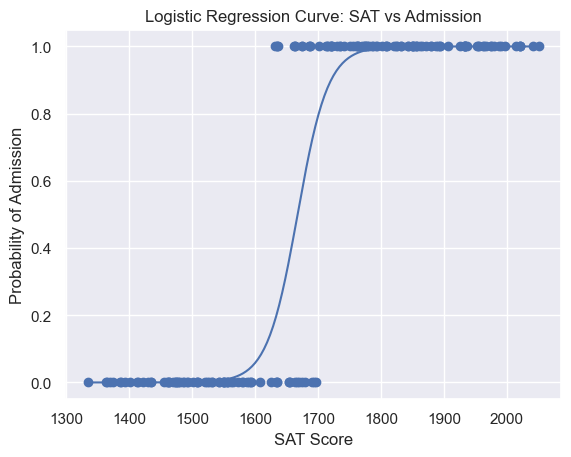

In [16]:


# Create SAT score range
sat_range = np.linspace(
    raw_data["SAT"].min(),
    raw_data["SAT"].max(),
    300
)

# Convert to DataFrame with correct column name
sat_range_df = pd.DataFrame(sat_range, columns=["SAT"])

# Predict probabilities
probabilities = model.predict_proba(sat_range_df)[:, 1]

# Plot
plt.figure()
plt.scatter(raw_data["SAT"], raw_data["Admitted"])
plt.plot(sat_range_df["SAT"], probabilities)
plt.xlabel("SAT Score")
plt.ylabel("Probability of Admission")
plt.title("Logistic Regression Curve: SAT vs Admission")
plt.show()

In [17]:
# Extract model parameters
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]

# SAT score where probability = 0.5
sat_cutoff = -beta_0 / beta_1

sat_cutoff

np.float64(1667.3902520064394)

In [18]:
# New student's SAT score
new_student = pd.DataFrame({"SAT": [1100]})

# Predict probability of admission
admission_probability = model.predict_proba(new_student)[0][1]

admission_probability

np.float64(6.668271923913001e-11)

In [19]:
# Multiple students' SAT scores
new_students = pd.DataFrame({
    "SAT": [900, 1000, 1100, 1200, 1300]
})
# Predict probabilities
probabilities = model.predict_proba(new_students)
# Create a clean results table
results = new_students.copy()
results["Prob_Not_Admitted"] = probabilities[:, 0]
results["Prob_Admitted"] = probabilities[:, 1]
results


,SAT,Prob_Not_Admitted,Prob_Admitted
0,900,1.0,1.726111e-14
1,1000,1.0,1.072855e-12
2,1100,1.0,6.668272e-11
3,1200,1.0,4.144628e-09
4,1300,1.0,2.576070e-07
